# 01 EDA – Titanic Survival Prediction

Exploratory Data Analysis for binary classification.

## Importing Libraries

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
# sns.set_style is used to set the aesthetic style of the plots created using the seaborn library.
# By calling sns.set_style("whitegrid"), we are specifying that we want to use the "whitegrid" style for our plots. 
# The "whitegrid" style adds a white background with gridlines to the plots, which can enhance the readability and visual appeal of the charts. This style is particularly useful for visualizing data distributions and relationships between variables, as the gridlines can help to better identify patterns and trends in the data.

In [16]:
# ### Load the Titanic dataset
# Read the raw CSV file into a pandas `DataFrame` and show the first few rows to inspect its structure.

In [17]:

df = pd.read_csv("../data/raw/Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Shape and Info
This gives us a hint about:<br>
	•	number of rows <br>
	•	missing values <br>
	•	data types <br>

In [18]:

df.shape


(891, 12)

In [19]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Target Variable Analysis
Analyze the distribution of the target variable (Survived) to understand class imbalance.<br>
The target shows mild class imbalance, so accuracy alone would be misleading. We will use precision, recall, and F1-score to evaluate<br> our model's performance on both classes.


In [20]:

df["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [21]:

df["Survived"].value_counts(normalize=True)


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

# Calculating missing values
Calculate the percentage of missing values for each feature to identify which features require imputation or removal.<br>
Expected observation:<br>
	•	Age has missing values <br>
	•	Some columns are irrelevant for baseline model <br>
Median could be used to impute Age, and we can drop irrelevant columns for the baseline model. <br>

In [22]:

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Feature Distributions
Visualize the distributions of numerical features (e.g., Age, Fare) using histograms or boxplots to identify skewness, outliers, and<br> appropriate transformations (e.g., log transformation for skewed features).<br>
Shown:<br>
    •	Age is skewed with outliers, so log transformation may help.<br>
    •	scale differences → justification for scaling<br>

In [23]:

df[["Age", "Fare"]].describe()


,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


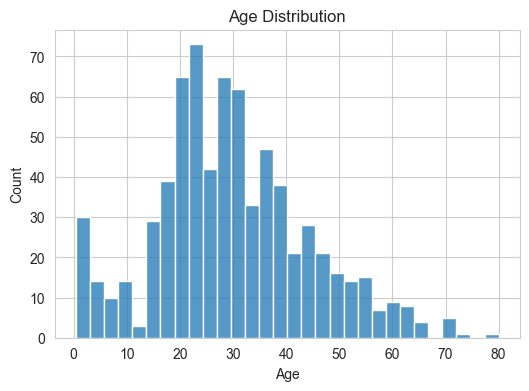

In [24]:

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.show()


# Categorical vs Target Analysis
Visualize the relationship between categorical features.<br>
For example, Sex appears strongly predictive of survival.

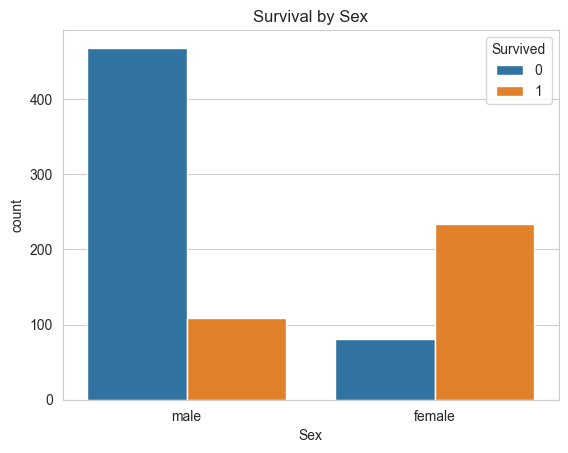

In [25]:

sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()


# Feature Selection Justification
For the baseline model, I selected a small, interpretable feature set **to reduce noise and overfitting**.<br>
Selected features:<br>
    •	Pclass: Reflects socio-economic status, which influenced survival chances.<br>
    •	Sex: Gender was a strong predictor of survival, with women having higher survival rates.<br>
    •	Age: Age influenced survival, with children and younger adults having better chances.<br>
    •	Fare: Higher fares may indicate better access to lifeboats or cabins, affecting survival.<br>
    •   Survived: Target variable for prediction.<br>

In [26]:
df[["Pclass", "Sex", "Age", "Fare", "Survived"]].head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0



## Summary

- Mild class imbalance observed  
- Missing values in Age  
- Sex strongly correlated with survival  

